# **C10 - Repaso integral: datos de mercado, payoffs y trayectorias de META**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 23 de septiembre de 2026

---

**Ejercicio:** recuperar los principales procedimientos trabajados durante el curso mediante datos reales de META, el cálculo de payoffs de opciones y la simulación de trayectorias del precio entre marzo y septiembre de 2026.

El notebook reúne en un mismo flujo la lectura de precios históricos, el análisis de rendimientos, la separación temporal entre entrenamiento y prueba y la generación de trayectorias mediante movimiento browniano geométrico, de modo que el precio real observado entre septiembre de 2025 y septiembre de 2026 pueda compararse con escenarios simulados sin cambiar la fórmula utilizada durante el curso.

## Índice de contenidos

1. Sección 1 — Datos históricos y payoffs de opciones
2. Sección 2 — Separación temporal y parámetros de simulación
3. Sección 3 — Generador de trayectorias
4. Sección 4 — Comparación entre precios reales y simulados
5. Sección 5 — Conclusiones

## Importación de bibliotecas

In [22]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

np.random.seed(23)

## 1. Datos históricos y payoffs de opciones

El primer bloque recupera el precio de cierre de META y sus rendimientos diarios, ya que ambas magnitudes cumplen funciones distintas en el análisis: el precio permite observar la evolución del activo, mientras que el rendimiento sirve para estimar la media y la desviación estándar que alimentarán la simulación posterior, y sobre ese mismo periodo se calculan además los pagos de opciones call y put europeas, asiáticas y lookback, con el fin de comparar cómo cambia el contrato cuando el subyacente es el precio final, el promedio del camino o un extremo de la trayectoria.

Los pagos se calculan con las funciones que se han utilizado en los ejercicios anteriores, donde $k$ es el precio inicial, $S_t$ el precio final y $\bar{S}$ el promedio observado:

$$C_{eur}=\max(S_t-k,0), \qquad P_{eur}=\max(k-S_t,0)$$

$$C_{asian}=\max(\bar{S}-k,0), \qquad P_{asian}=\max(k-\bar{S},0)$$

$$C_{lookback}=\max(S_t-\min(S),0), \qquad P_{lookback}=\max(\max(S)-S_t,0)$$

In [23]:
Prices = yf.download("META", period="6mo")["Close"]
Prices

[*********************100%***********************]  1 of 1 completed


Ticker,META
Date,
2026-03-24,591.903870
2026-03-25,593.870483
2026-03-26,546.601562
2026-03-27,524.818970
2026-03-30,535.460754
...,...
2026-09-17,681.771973
2026-09-18,665.225037
2026-09-21,741.250000


C:\Users\franc\AppData\Local\Temp\ipykernel_42236\1727659306.py:2: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(Prices.index, Prices.values, linestyle='-', marker='o', markersize=3, linewidth=1)
C:\Users\franc\AppData\Local\Temp\ipykernel_42236\1727659306.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(Prices.index, Prices.values, linestyle='-', marker='o', markersize=3, linewidth=1)


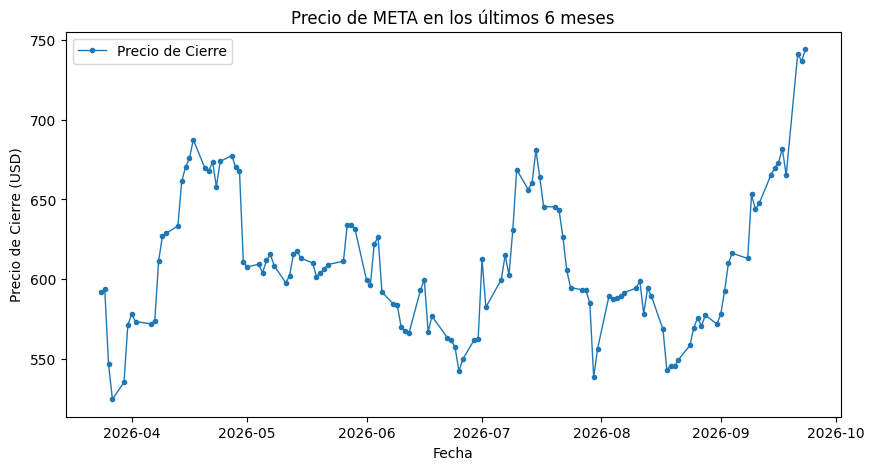

In [24]:
plt.figure(figsize=(10, 5))
plt.plot_date(Prices.index, Prices.values, linestyle='-', marker='o', markersize=3, linewidth=1)
plt.title("Precio de META en los últimos 6 meses")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.legend(["Precio de Cierre"])
plt.show()

La serie recorre 127 cierres entre el 24 de marzo y el 23 de septiembre de 2026, con un avance de 591.90 a 744.10 dólares que pasa por un mínimo de 524.82 el 27 de marzo, y funciona como referencia visual para el resto del notebook, aunque la comparación anual de precios se construirá después con una descarga que separa el tramo de entrenamiento y el tramo de prueba.

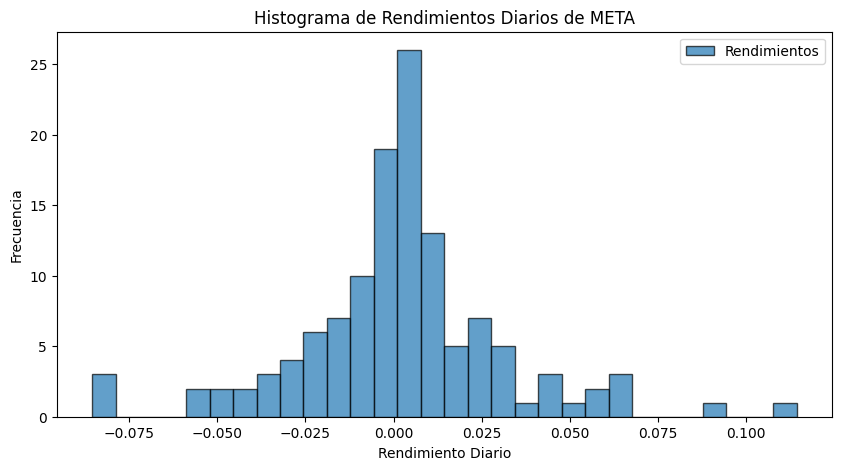

In [25]:
Rendimientos = Prices.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.hist(Rendimientos, bins=30, edgecolor='black', alpha=0.7)
plt.title("Histograma de Rendimientos Diarios de META")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Frecuencia")
plt.legend(["Rendimientos"])
plt.show()

El histograma concentra los rendimientos alrededor de cero y permite observar su dispersión diaria, que es la escala adecuada para estimar el movimiento de un día hábil, ya que la media resume el componente promedio del cambio mientras que la desviación estándar mide la incertidumbre que se propagará en cada paso de las trayectorias simuladas.

In [31]:
Close = Prices.iloc[:, 0].values
k = Close[0]
St = Close[-1]

payoff_call_eur = np.maximum(St - k, 0)
payoff_put_eur = np.maximum(k - St, 0)

payoff_asian_call = np.maximum(Close.mean() - k, 0)
payoff_asian_put = np.maximum(k - Close.mean(), 0)

payoff_lookback_call = np.maximum(St - Close.min(), 0)
payoff_lookback_put = np.maximum(Close.max() - St, 0)

print("Payoff de la opción call europea:", payoff_call_eur)
print("Payoff de la opción put europea:", payoff_put_eur)

print("Payoff de la opción call asiática:", payoff_asian_call)
print("Payoff de la opción put asiática:", payoff_asian_put)

print("Payoff de la opción call lookback:", payoff_lookback_call)
print("Payoff de la opción put lookback:", payoff_lookback_put)

Payoff de la opción call europea: 152.19610595703125
Payoff de la opción put europea: 0.0
Payoff de la opción call asiática: 17.755994421290552
Payoff de la opción put asiática: 0.0
Payoff de la opción call lookback: 219.281005859375
Payoff de la opción put lookback: 0.0


Los payoffs muestran que cada contrato responde a una referencia distinta del precio, pues la call europea paga 152.1961 dólares por la distancia entre el cierre de 744.10 y el strike de 591.90, la call asiática apenas 17.7560 porque el promedio del semestre queda muy por debajo del precio final, y la call lookback 219.2810 al medirse contra el mínimo de 524.82.

Las tres versiones put valen cero sin excepción, resultado que no es una anomalía sino la consecuencia directa de que META cerró el periodo en su propio máximo, de modo que ni el precio final, ni el promedio, ni el extremo quedaron por debajo del strike, y esa asimetría entre call y put confirma que no basta con conocer el último precio para inferir el valor de todos los contratos.

## 2. Separación temporal y parámetros de simulación

In [85]:
Prices_train = yf.download("META", start="2025-09-22", end="2026-03-25")["Close"]
Prices_test = yf.download("META", start="2026-03-25", end="2026-09-24")["Close"]
Prices_real = pd.concat([Prices_train, Prices_test]).loc[lambda prices: ~prices.index.duplicated(keep="first")]

mean = Prices_train.pct_change().mean()
std = Prices_train.pct_change().std()
P_t = Prices_train.values.flatten()
P_t[-1]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


np.float64(591.9038696289062)

Para comparar observación y simulación sin contaminar la estimación, el periodo se divide temporalmente: los precios de septiembre de 2025 a marzo de 2026 forman el conjunto de entrenamiento, mientras que los de marzo a septiembre de 2026 se reservan como referencia de prueba, de manera que la media y la desviación estándar se calculan únicamente con el primer tramo y el histórico completo se conserva para visualizar la comparación anual, tomando como punto de partida de la simulación el último cierre del entrenamiento, 591.90 dólares del 24 de marzo de 2026.

## 3. Generador de trayectorias

In [72]:
def create_paths(S0, r, std, T, n, M):
    dt = T / n
    paths = np.zeros((M, n + 1))
    paths[:, 0] = S0
    for i in range(1, n + 1):
        Z = np.random.standard_normal(M)
        paths[:, i] = paths[:, i - 1] * np.exp((r - 0.5 * std ** 2) * dt + std * np.sqrt(dt) * Z)
    return paths

El precio se propaga mediante el movimiento browniano geométrico que se ha utilizado en los ejercicios anteriores, donde cada paso toma como punto de partida el precio del día previo y aplica una deriva corregida por la varianza junto con una perturbación normal.

$$S_{t+\Delta t} = S_t \exp\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right], \qquad Z \sim N(0,1)$$

Como `std` corresponde a rendimientos diarios, se fija $T=n$ para que $\Delta t=T/n=1$ y cada iteración represente un día hábil, mientras que la función devuelve una matriz de $M$ trayectorias y $n+1$ puntos por trayectoria, ya que conserva también el precio inicial, con lo cual la forma de `Paths` permite graficar cada fila como un camino completo desde marzo hasta septiembre de 2026.

In [86]:
M = 10000
n = len(pd.bdate_range(start=Prices_train.index[-1], end=Prices_real.index[-1])) - 1

Paths = create_paths(S0 = P_t[-1], r = mean.values[0], std = std.values[0], T = n, n = n, M = M)
Paths.shape

(10000, 132)

La simulación conserva 10,000 escenarios y utiliza 131 pasos, tantos como días hábiles existen entre el último precio del entrenamiento y el cierre del periodo de prueba, de manera que la matriz resultante tiene forma (10000, 132) al incluir también el precio inicial y cada trayectoria termina en la misma fecha que el tramo real reservado para la comparación.

## 4. Comparación entre precios reales y simulados

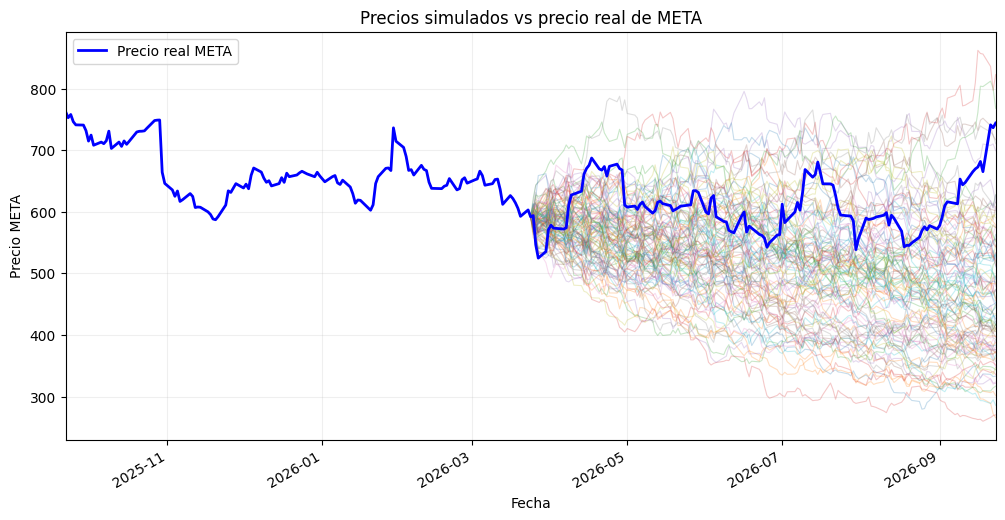

In [87]:
dias_real = Prices_real.index
dias_sim = pd.bdate_range(start=Prices_train.index[-1], periods=Paths.shape[1])

plt.figure(figsize=(12, 6))

for trayectoria in Paths[:100]:
    plt.plot(dias_sim, trayectoria, lw=0.8, alpha=0.25)

plt.plot(dias_real, Prices_real.values.flatten(), lw=2, color='blue', label='Precio real META')

plt.title('Precios simulados vs precio real de META')
plt.xlabel('Fecha')
plt.ylabel('Precio META')
plt.legend()
plt.grid(alpha=0.2)
plt.xlim(dias_real[0], dias_real[-1])
plt.gcf().autofmt_xdate()
plt.show()

La línea azul recorre el histórico completo de septiembre de 2025 a septiembre de 2026, mientras que las cien trayectorias graficadas comienzan en marzo de 2026, exactamente en el punto donde termina el entrenamiento, y el abanico que forman refleja la incertidumbre acumulada por el proceso en lugar de una predicción única, por ello algunas terminan por encima del precio observado y otras por debajo aunque todas parten del mismo valor inicial.

La comparación debe leerse como una evaluación visual de escenarios y no como una validación de que una trayectoria individual reproduzca el mercado, ya que el movimiento browniano geométrico genera realizaciones posibles a partir de la media y la desviación estimadas, mientras que la serie azul corresponde a una sola realización histórica.

## 5. Conclusiones

El repaso confirma que la simulación depende de una separación temporal coherente, ya que los rendimientos de septiembre de 2025 a marzo de 2026 estiman los parámetros y esos parámetros generan los 10,000 escenarios que parten de 591.90 dólares hacia el periodo de marzo a septiembre de 2026, el cual se contrasta después con el precio real dentro de una gráfica anual.

El bloque de payoffs deja además una lectura que conviene no perder entre los procedimientos, pues las tres versiones call pagan 152.1961, 17.7560 y 219.2810 dólares mientras que las tres put valen cero sobre la misma serie, con lo cual la elección del subyacente de referencia —precio final, promedio o extremo— pesa tanto sobre el resultado como la dirección que tomó el mercado.

La principal ventaja de conservar la matriz completa de trayectorias es que el mismo generador puede alimentar análisis posteriores sobre precios finales, promedios y extremos, aunque la gráfica por sí sola no determina cuál escenario ocurrirá ni sustituye una evaluación estadística de los errores de pronóstico.

El límite metodológico central es que la media y la desviación estándar se estiman con un único tramo histórico y bajo la hipótesis de rendimientos estacionarios, por lo cual los escenarios no incorporan cambios de régimen, saltos ni dependencia temporal más allá de la estructura del movimiento browniano geométrico, mientras que la extensión natural sería comparar métricas del tramo de prueba, como el error entre el precio real y el promedio simulado, sin modificar el generador utilizado en este repaso.